Dataset shape: (50000, 2)

Columns: ['review', 'sentiment']

Missing values:
 review       0
sentiment    0
dtype: int64

Total samples: 50000

Class distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


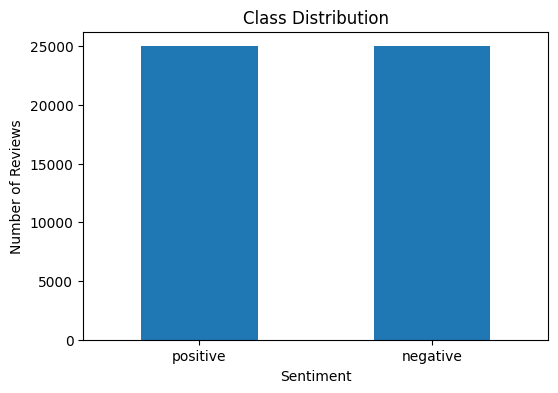


Word count statistics:
count    50000.000000
mean       234.183920
std        173.512711
min          6.000000
25%        128.000000
50%        176.000000
75%        284.000000
max       2494.000000
Name: word_count, dtype: float64

Sentence count statistics:
count    50000.000000
mean        13.272080
std          9.271855
min          1.000000
25%          7.000000
50%         11.000000
75%         16.000000
max        150.000000
Name: sentence_count, dtype: float64

Character count statistics:
count    50000.000000
mean      1309.431020
std        989.728014
min         32.000000
25%        699.000000
50%        970.000000
75%       1590.250000
max      13704.000000
Name: char_count, dtype: float64

Minimum text length (words): 6
Maximum text length (words): 2494


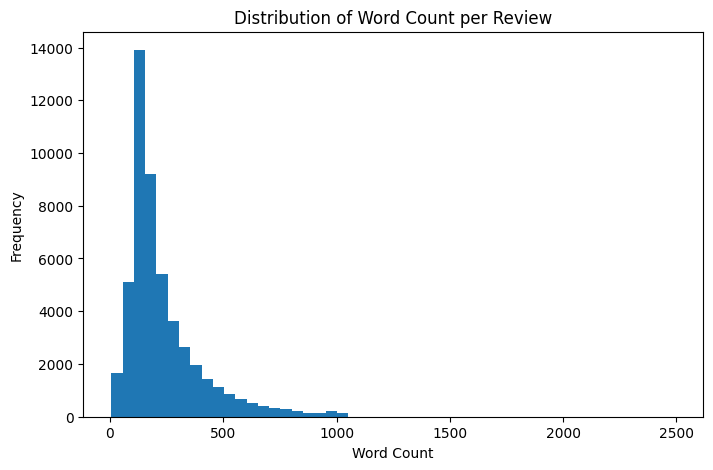

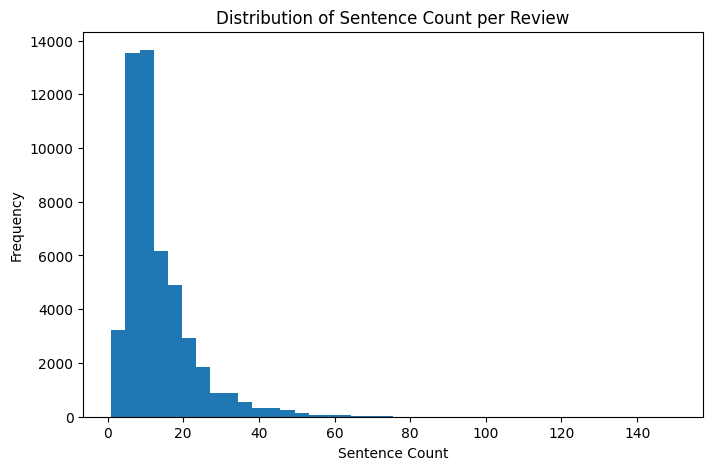

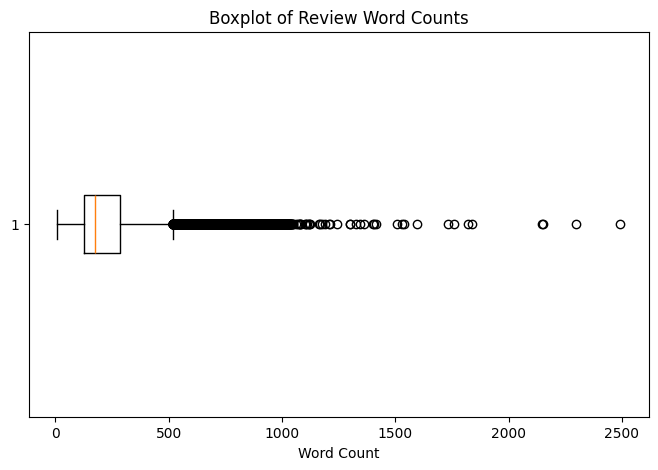


Average word count per document: 234.18
Average sentence count per document: 13.27
Average characters per document: 1309.43


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (563 > 512). Running this sequence through the model will result in indexing errors



Token count statistics:
count    50000.000000
mean       310.321160
std        231.142078
min         10.000000
25%        167.000000
50%        231.000000
75%        377.000000
max       3157.000000
Name: token_count, dtype: float64

Number of reviews exceeding 512 tokens: 7214
Percentage exceeding 512 tokens: 14.43%


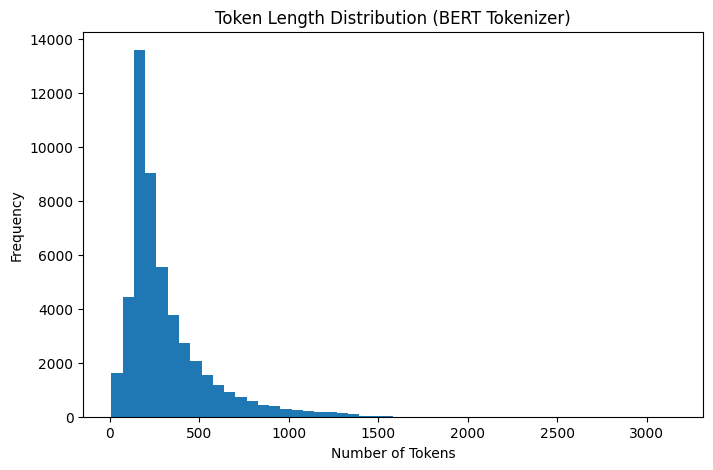


Top 20 Positive Words:
          word  frequency
0         like      17714
1         good      15025
2         just      14109
3        great      12964
4        story      12935
5         time      12752
6       people       8719
7         love       8692
8         best       8510
9         life       8139
10         way       7865
11       films       7601
12       think       7208
13  characters       7103
14         don       7001
15      movies       6996
16   character       6925
17         man       6762
18        seen       6760
19       watch       6727

Top 20 Negative Words:
          word  frequency
0         like      22458
1         just      21074
2         good      14728
3          bad      14726
4         time      12357
5          don      10622
6        story      10186
7       people       9469
8         make       9354
9       movies       8313
10        plot       8214
11      acting       8087
12         way       7780
13  characters       7353
14       watch  

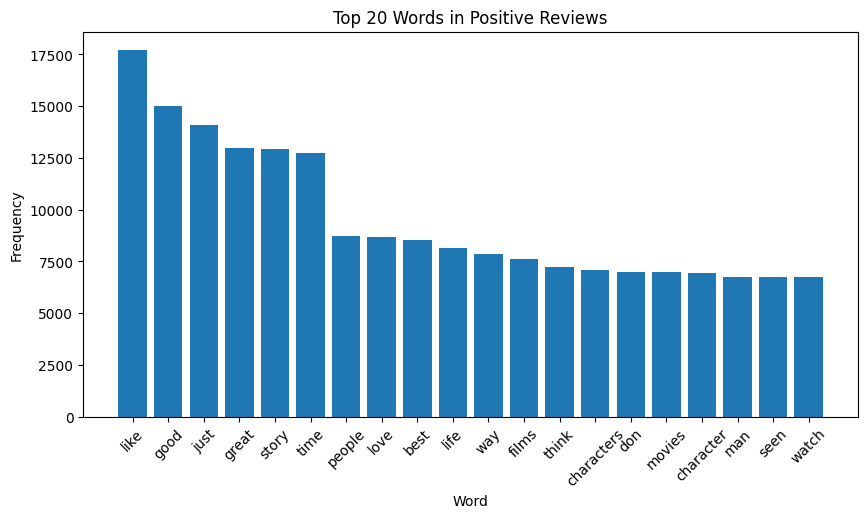

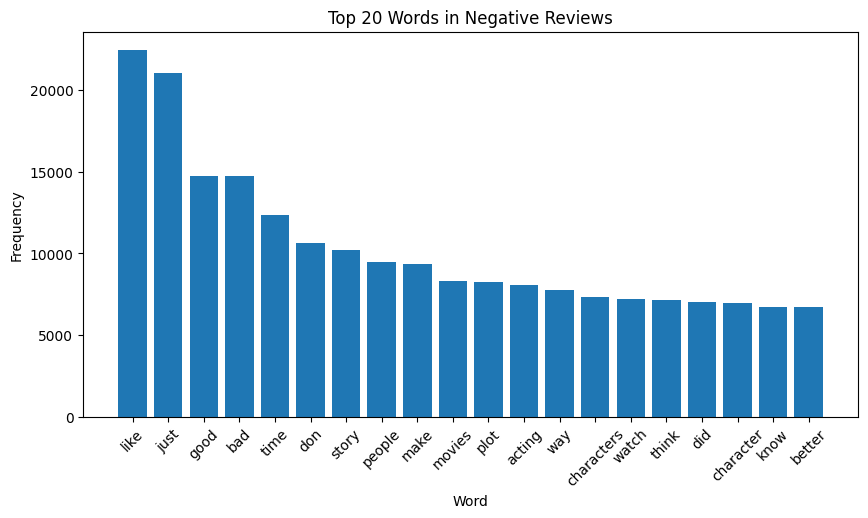


EDA Summary Table:
                   Metric          Value
0           Total samples          50000
1       Number of classes              2
2      Average word count         234.18
3  Average sentence count          13.27
4      Minimum word count              6
5      Maximum word count           2494
6     Average token count         310.32
7    Reviews > 512 tokens  7214 (14.43%)


In [ ]:
# ============================================
# Exploratory Data Analysis (EDA) for IMDB 50K
# ============================================

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from transformers import AutoTokenizer

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("/content/IMDB Dataset.csv")   # make sure the file name matches yours

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())

# ----------------------------
# 2. Basic dataset statistics
# ----------------------------
print("\nTotal samples:", len(df))
print("\nClass distribution:")
print(df["sentiment"].value_counts())

plt.figure(figsize=(6,4))
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

# ----------------------------
# 3. Cleaning helper functions
# ----------------------------
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)          # remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", " ", text)    # keep only letters
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

def sentence_count(text):
    sentences = re.split(r"[.!?]+", str(text))
    sentences = [s.strip() for s in sentences if s.strip()]
    return len(sentences)

def word_count(text):
    return len(str(text).split())

# Keep original text and cleaned text
df["clean_review"] = df["review"].apply(clean_text)

# ----------------------------
# 4. Text length statistics
# ----------------------------
df["word_count"] = df["clean_review"].apply(word_count)
df["sentence_count"] = df["review"].apply(sentence_count)
df["char_count"] = df["review"].astype(str).apply(len)

print("\nWord count statistics:")
print(df["word_count"].describe())

print("\nSentence count statistics:")
print(df["sentence_count"].describe())

print("\nCharacter count statistics:")
print(df["char_count"].describe())

print("\nMinimum text length (words):", df["word_count"].min())
print("Maximum text length (words):", df["word_count"].max())

# ----------------------------
# 5. Length distribution plots
# ----------------------------
plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=50)
plt.title("Distribution of Word Count per Review")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df["sentence_count"], bins=40)
plt.title("Distribution of Sentence Count per Review")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
plt.boxplot(df["word_count"], vert=False)
plt.title("Boxplot of Review Word Counts")
plt.xlabel("Word Count")
plt.show()

# ----------------------------
# 6. Average statistics
# ----------------------------
print("\nAverage word count per document:", round(df["word_count"].mean(), 2))
print("Average sentence count per document:", round(df["sentence_count"].mean(), 2))
print("Average characters per document:", round(df["char_count"].mean(), 2))

# ----------------------------
# 7. Token length distribution using BERT tokenizer
# ----------------------------
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

df["token_count"] = df["review"].apply(lambda x: len(tokenizer.encode(str(x), truncation=False)))

print("\nToken count statistics:")
print(df["token_count"].describe())

over_512 = (df["token_count"] > 512).sum()
percent_over_512 = (over_512 / len(df)) * 100

print("\nNumber of reviews exceeding 512 tokens:", over_512)
print("Percentage exceeding 512 tokens: {:.2f}%".format(percent_over_512))

plt.figure(figsize=(8,5))
plt.hist(df["token_count"], bins=50)
plt.title("Token Length Distribution (BERT Tokenizer)")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()

# ----------------------------
# 8. Top 20 positive and negative words
# ----------------------------
custom_stopwords = set(ENGLISH_STOP_WORDS).union({
    "movie", "film", "one", "would", "could", "also", "get", "even", "really"
})

def get_words(text):
    words = str(text).split()
    words = [w for w in words if w not in custom_stopwords and len(w) > 2]
    return words

positive_words = []
negative_words = []

for text in df[df["sentiment"] == "positive"]["clean_review"]:
    positive_words.extend(get_words(text))

for text in df[df["sentiment"] == "negative"]["clean_review"]:
    negative_words.extend(get_words(text))

top20_pos = Counter(positive_words).most_common(20)
top20_neg = Counter(negative_words).most_common(20)

pos_df = pd.DataFrame(top20_pos, columns=["word", "frequency"])
neg_df = pd.DataFrame(top20_neg, columns=["word", "frequency"])

print("\nTop 20 Positive Words:")
print(pos_df)

print("\nTop 20 Negative Words:")
print(neg_df)

plt.figure(figsize=(10,5))
plt.bar(pos_df["word"], pos_df["frequency"])
plt.title("Top 20 Words in Positive Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(neg_df["word"], neg_df["frequency"])
plt.title("Top 20 Words in Negative Reviews")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

# ----------------------------
# 9. Compact summary table
# ----------------------------
summary_table = pd.DataFrame({
    "Metric": [
        "Total samples",
        "Number of classes",
        "Average word count",
        "Average sentence count",
        "Minimum word count",
        "Maximum word count",
        "Average token count",
        "Reviews > 512 tokens"
    ],
    "Value": [
        len(df),
        df["sentiment"].nunique(),
        round(df["word_count"].mean(), 2),
        round(df["sentence_count"].mean(), 2),
        df["word_count"].min(),
        df["word_count"].max(),
        round(df["token_count"].mean(), 2),
        f"{over_512} ({percent_over_512:.2f}%)"
    ]
})

print("\nEDA Summary Table:")
print(summary_table)


===== Dataset Overview =====


,Metric,Value
0,Total Samples,50000
1,Number of Classes,2
2,Positive Reviews,25000
3,Negative Reviews,25000
4,Average Word Count,234.18
5,Average Sentence Count,13.27
6,Minimum Word Count,6
7,Maximum Word Count,2494
8,Average Token Count,310.32
9,Reviews > 512 Tokens,7214 (14.43%)


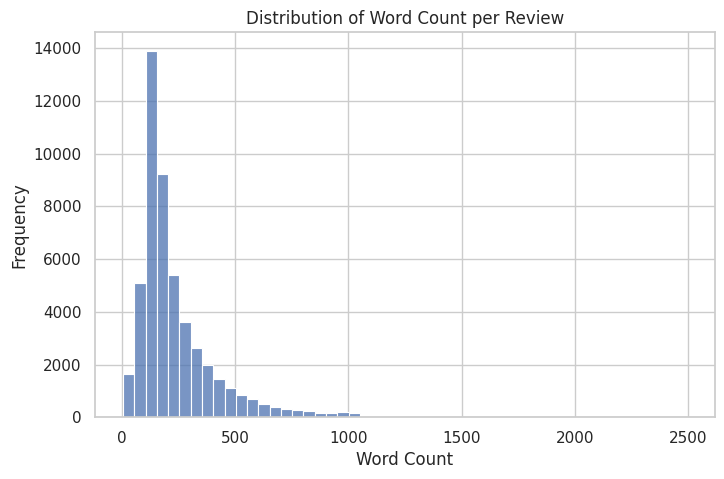

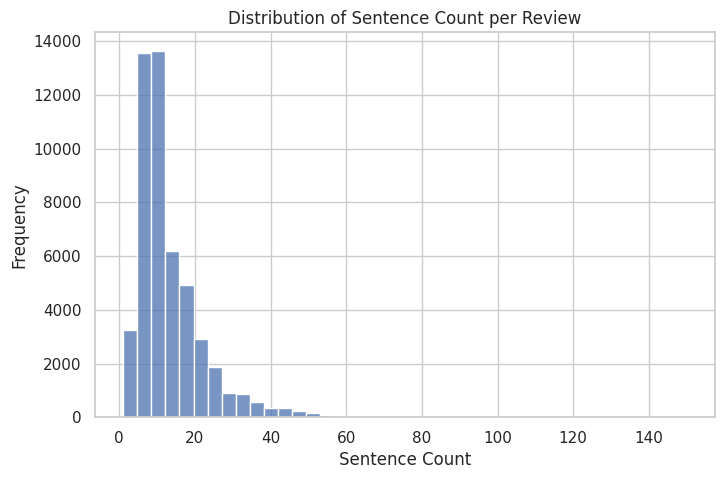

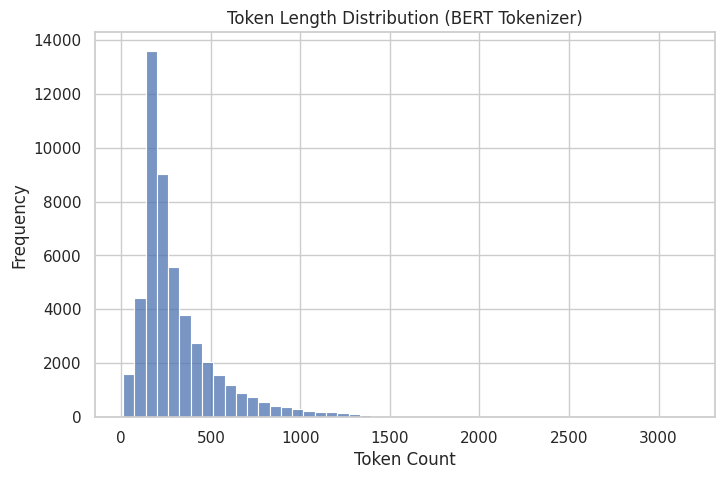

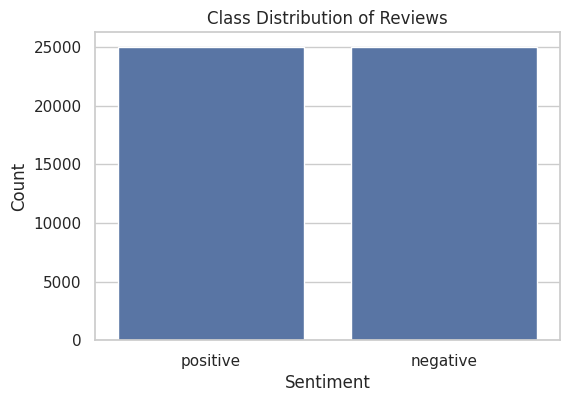

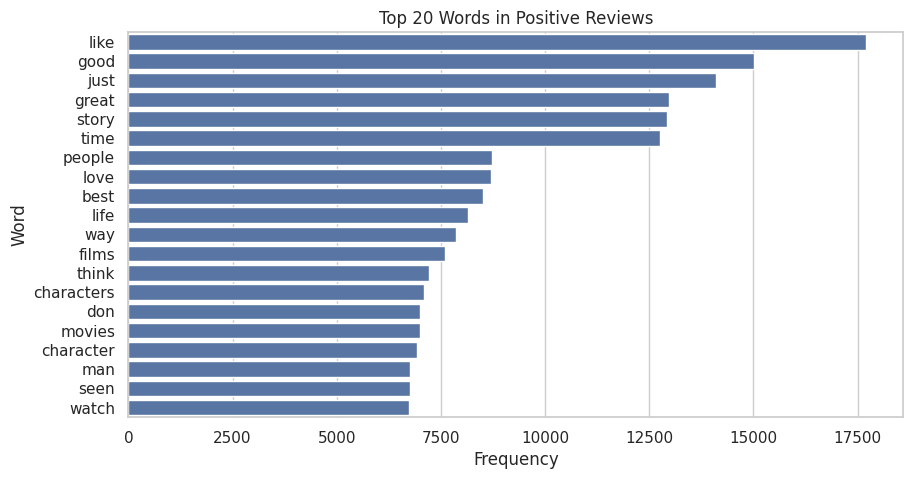

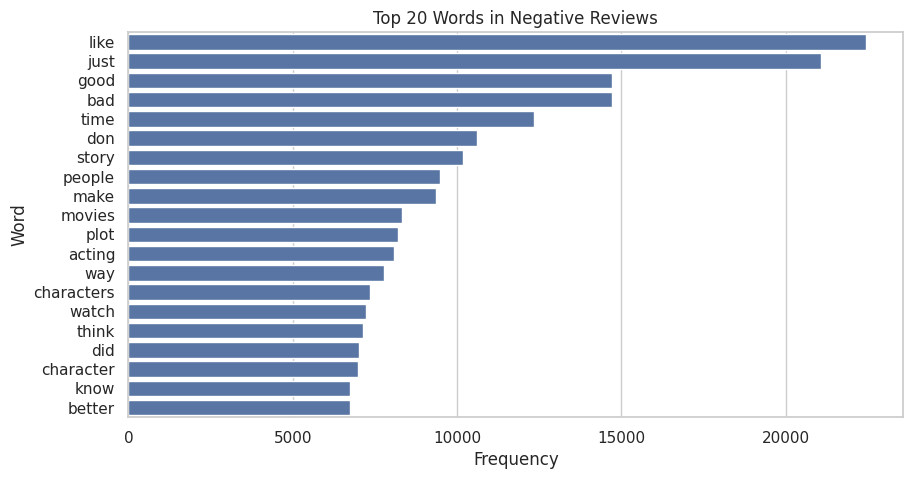

In [ ]:
# ============================
# Display EDA results nicely
# ============================

from IPython.display import display
import seaborn as sns

sns.set(style="whitegrid")

# ----------------------------
# 1. Dataset Summary Table
# ----------------------------
summary_table = pd.DataFrame({
    "Metric": [
        "Total Samples",
        "Number of Classes",
        "Positive Reviews",
        "Negative Reviews",
        "Average Word Count",
        "Average Sentence Count",
        "Minimum Word Count",
        "Maximum Word Count",
        "Average Token Count",
        "Reviews > 512 Tokens"
    ],
    "Value": [
        len(df),
        df["sentiment"].nunique(),
        df["sentiment"].value_counts()["positive"],
        df["sentiment"].value_counts()["negative"],
        round(df["word_count"].mean(),2),
        round(df["sentence_count"].mean(),2),
        df["word_count"].min(),
        df["word_count"].max(),
        round(df["token_count"].mean(),2),
        f"{over_512} ({percent_over_512:.2f}%)"
    ]
})

print("\n===== Dataset Overview =====")
display(summary_table)

# ----------------------------
# 2. Word Count Distribution
# ----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["word_count"], bins=50)
plt.title("Distribution of Word Count per Review")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

# ----------------------------
# 3. Sentence Count Distribution
# ----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["sentence_count"], bins=40)
plt.title("Distribution of Sentence Count per Review")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.show()

# ----------------------------
# 4. Token Length Distribution
# ----------------------------
plt.figure(figsize=(8,5))
sns.histplot(df["token_count"], bins=50)
plt.title("Token Length Distribution (BERT Tokenizer)")
plt.xlabel("Token Count")
plt.ylabel("Frequency")
plt.show()

# ----------------------------
# 5. Class Distribution
# ----------------------------
plt.figure(figsize=(6,4))
sns.countplot(x="sentiment", data=df)
plt.title("Class Distribution of Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# ----------------------------
# 6. Top Positive Words
# ----------------------------
plt.figure(figsize=(10,5))
sns.barplot(x="frequency", y="word", data=pos_df)
plt.title("Top 20 Words in Positive Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

# ----------------------------
# 7. Top Negative Words
# ----------------------------
plt.figure(figsize=(10,5))
sns.barplot(x="frequency", y="word", data=neg_df)
plt.title("Top 20 Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

In [ ]:
# ======================================
# Compression Analysis for Summarisation
# ======================================

import numpy as np

def first_n_sentences(text, n=3):
    sentences = re.split(r"[.!?]+", str(text))
    sentences = [s.strip() for s in sentences if s.strip()]
    return " ".join(sentences[:n])

# Generate pseudo summaries
df["summary_3_sent"] = df["review"].apply(lambda x: first_n_sentences(x,3))
df["summary_2_sent"] = df["review"].apply(lambda x: first_n_sentences(x,2))

# Calculate word counts
df["summary3_words"] = df["summary_3_sent"].apply(lambda x: len(x.split()))
df["summary2_words"] = df["summary_2_sent"].apply(lambda x: len(x.split()))

compression_table = pd.DataFrame({
    "Text Version":[
        "Full Review",
        "3 Sentence Summary",
        "2 Sentence Summary"
    ],
    "Average Words":[
        round(df["word_count"].mean(),2),
        round(df["summary3_words"].mean(),2),
        round(df["summary2_words"].mean(),2)
    ]
})

print("\nCompression Analysis:")
display(compression_table)


Compression Analysis:


,Text Version,Average Words
0,Full Review,234.18
1,3 Sentence Summary,56.08
2,2 Sentence Summary,37.31


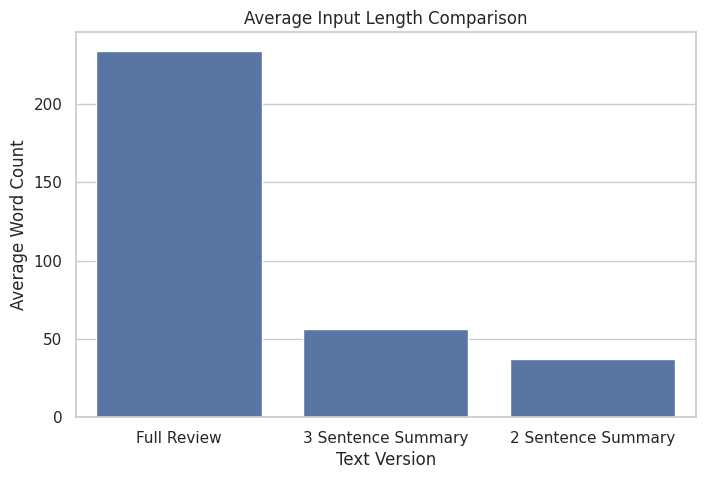

In [ ]:
# ======================================
# Compression Visualization
# ======================================

compression_plot = pd.DataFrame({
    "Text Version": [
        "Full Review",
        "3 Sentence Summary",
        "2 Sentence Summary"
    ],
    "Average Words": [
        234.18,
        56.08,
        37.31
    ]
})

plt.figure(figsize=(8,5))
sns.barplot(x="Text Version", y="Average Words", data=compression_plot)

plt.title("Average Input Length Comparison")
plt.xlabel("Text Version")
plt.ylabel("Average Word Count")

plt.show()

In [ ]:
plt.savefig("compression_comparison.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>